# 03 - Comparación y selección de modelos

Este notebook entrena varios algoritmos, compara su rendimiento y guarda el mejor pipeline para explicabilidad y fairness.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## Carga y preparación de datos

Se normalizan nombres de columnas, se define el objetivo binario y se preparan los predictores que se usarán en todos los modelos.

In [2]:
df = pd.read_csv("../data/dataset.csv")
df.columns = df.columns.str.strip()
df["Target_bin"] = (df["Target"] == "Dropout").astype(int)

In [3]:
drop_cols = [
    "Target",
    "Target_bin",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

X = df.drop(columns=drop_cols)
y = df["Target_bin"]

## Tipos de variables

Se distinguen variables categóricas y numéricas para aplicar transformaciones adecuadas dentro del pipeline de scikit-learn.

In [4]:
categorical_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

numeric_features = [col for col in X.columns if col not in categorical_features]

print("NumÃƒÂ©ricas:", len(numeric_features))
print("CategÃƒÂ³ricas:", len(categorical_features))

NumÃƒÂ©ricas: 10
CategÃƒÂ³ricas: 18


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(3539, 28) (885, 28)


## Modelos candidatos

Se definen algoritmos lineales, árboles, bosques, boosting y SVM. La comparación cubre modelos interpretables y modelos con mayor capacidad predictiva.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

In [7]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Ajuste de hiperparámetros

Las búsquedas con `GridSearchCV` prueban configuraciones relevantes para SVM, Random Forest y Gradient Boosting antes de la comparación final.

In [8]:
from sklearn.model_selection import GridSearchCV

svm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

svm_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto"]
}

svm_search = GridSearchCV(
    svm_pipe,
    svm_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_search.fit(X_train, y_train)
print(svm_search.best_params_)
print(svm_search.best_score_)

{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
0.7539586321241113


In [9]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = GridSearchCV(
    rf_pipe,
    rf_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print(rf_search.best_params_)
print(rf_search.best_score_)

{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
0.73687538455078


In [10]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

gb_search = GridSearchCV(
    gb_pipe,
    gb_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gb_search.fit(X_train, y_train)
print(gb_search.best_params_)
print(gb_search.best_score_)

{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
0.76132967670078


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": rf_search.best_estimator_.named_steps["model"],
    "Gradient Boosting": gb_search.best_estimator_.named_steps["model"],
    "SVM": svm_search.best_estimator_.named_steps["model"]
}

## Función de evaluación

La función común entrena cada pipeline y calcula métricas de test con el mismo criterio, lo que hace la comparación más limpia.

In [12]:
def evaluate_model(name, model, preprocessor, X_train, X_test, y_train, y_test):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    return pipe, results

In [13]:
trained_models = {}
results = []

for name, model in models.items():
    pipe, metrics = evaluate_model(name, model, preprocessor, X_train, X_test, y_train, y_test)
    trained_models[name] = pipe
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.871186,0.863248,0.711268,0.779923,0.912400
3,Gradient Boosting,0.859887,0.830579,0.707746,0.764259,0.907701
4,SVM,0.862147,0.864865,0.676056,0.758893,0.903790
2,Random Forest,0.858757,0.853333,0.676056,0.754420,0.901848
1,Decision Tree,0.783051,0.659722,0.669014,0.664336,0.752976


## Comparación con validación cruzada

Se usa validación cruzada para contrastar precisión, recall, F1 y ROC-AUC. La selección final se apoya en estas métricas, no solo en el test.

In [14]:
cv_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV F1", ascending=False)
cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
3,Gradient Boosting,0.858437,0.830573,0.703578,0.761330,0.898908
0,Logistic Regression,0.858434,0.831555,0.701812,0.760885,0.902291
4,SVM,0.856171,0.836531,0.686865,0.753959,0.897457
2,Random Forest,0.849393,0.840248,0.656983,0.736875,0.891299
1,Decision Tree,0.777910,0.652146,0.664008,0.657823,0.747916


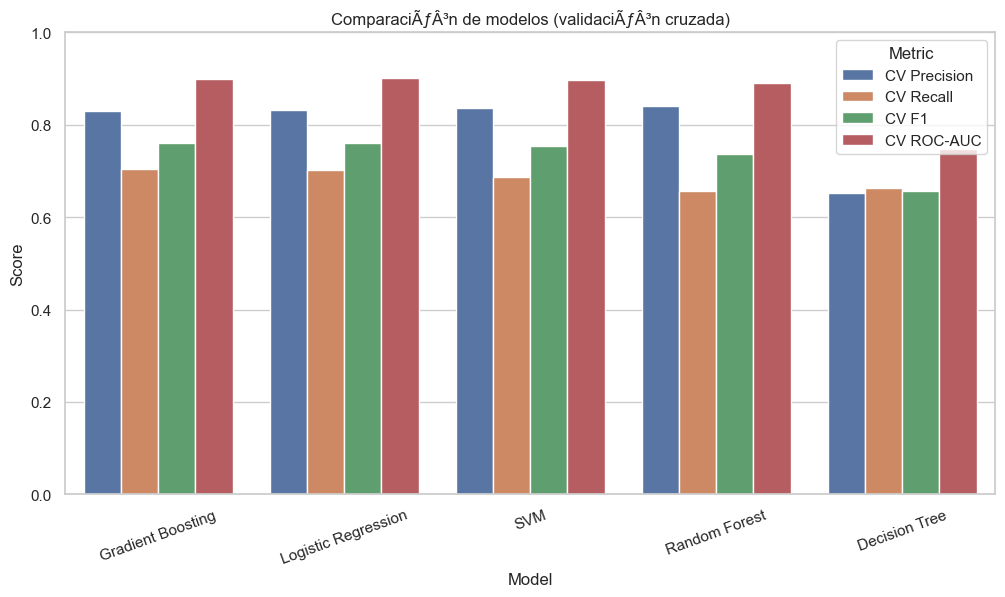

In [15]:
plot_df = cv_results_df.melt(
    id_vars="Model",
    value_vars=["CV Precision", "CV Recall", "CV F1", "CV ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.xticks(rotation=20)
plt.title("ComparaciÃƒÂ³n de modelos (validaciÃƒÂ³n cruzada)")
plt.ylim(0, 1)
plt.show()

In [16]:
best_model_name = cv_results_df.iloc[0]["Model"]
best_model_name

'Gradient Boosting'

In [17]:
final_comparison = results_df.merge(cv_results_df, on="Model")
final_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.871186,0.863248,0.711268,0.779923,0.912400,0.858434,0.831555,0.701812,0.760885,0.902291
1,Gradient Boosting,0.859887,0.830579,0.707746,0.764259,0.907701,0.858437,0.830573,0.703578,0.761330,0.898908
2,SVM,0.862147,0.864865,0.676056,0.758893,0.903790,0.856171,0.836531,0.686865,0.753959,0.897457
3,Random Forest,0.858757,0.853333,0.676056,0.754420,0.901848,0.849393,0.840248,0.656983,0.736875,0.891299
4,Decision Tree,0.783051,0.659722,0.669014,0.664336,0.752976,0.777910,0.652146,0.664008,0.657823,0.747916


In [18]:
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())
print(results_df)
print(cv_results_df.sort_values("CV F1", ascending=False))

(3539, 28) (885, 28)
0.3212771969482905 0.32090395480225986
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.871186   0.863248  0.711268  0.779923  0.912400
3    Gradient Boosting  0.859887   0.830579  0.707746  0.764259  0.907701
4                  SVM  0.862147   0.864865  0.676056  0.758893  0.903790
2        Random Forest  0.858757   0.853333  0.676056  0.754420  0.901848
1        Decision Tree  0.783051   0.659722  0.669014  0.664336  0.752976
                 Model  CV Accuracy  CV Precision  CV Recall     CV F1  \
3    Gradient Boosting     0.858437      0.830573   0.703578  0.761330   
0  Logistic Regression     0.858434      0.831555   0.701812  0.760885   
4                  SVM     0.856171      0.836531   0.686865  0.753959   
2        Random Forest     0.849393      0.840248   0.656983  0.736875   
1        Decision Tree     0.777910      0.652146   0.664008  0.657823   

   CV ROC-AUC  
3    0.898908  
0    0.902291  
4  

## Resultados finales y artefactos

Se guardan tablas, figuras y predicciones del mejor modelo. Estos archivos alimentan los notebooks de SHAP y fairness.

In [19]:
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/models", exist_ok=True)

final_comparison = final_comparison.sort_values(by="CV F1", ascending=False)

results_df.to_csv("../results/tables/test_results.csv", index=False)
cv_results_df.to_csv("../results/tables/cv_results.csv", index=False)
final_comparison.to_csv("../results/tables/final_model_comparison.csv", index=False)

In [20]:
best_model_name = cv_results_df.iloc[0]["Model"]
best_model_name

best_pipe = trained_models[best_model_name]

y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)

print("Modelo seleccionado:", best_model_name)
print("Matriz de confusiÃƒÂ³n:")
print(cm)

Modelo seleccionado: Gradient Boosting
Matriz de confusiÃƒÂ³n:
[[560  41]
 [ 83 201]]


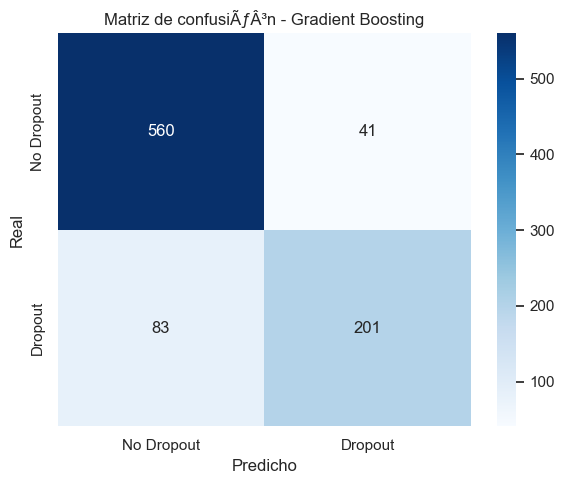

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Dropout", "Dropout"],
    yticklabels=["No Dropout", "Dropout"]
)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title(f"Matriz de confusiÃƒÂ³n - {best_model_name}")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_best_model.png", dpi=300)
plt.show()

<Figure size 600x500 with 0 Axes>

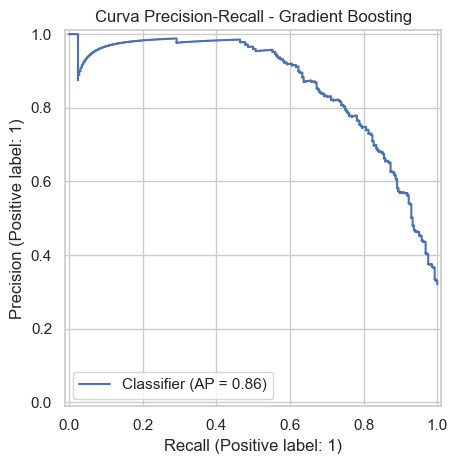

<Figure size 600x500 with 0 Axes>

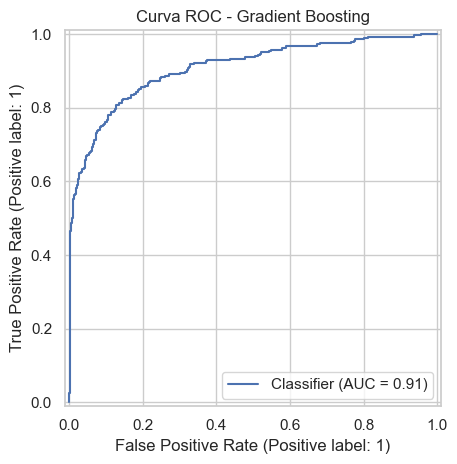

In [22]:
plt.figure(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_best)
plt.title(f"Curva Precision-Recall - {best_model_name}")
plt.tight_layout()
plt.savefig("../results/figures/pr_curve_best_model.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title(f"Curva ROC - {best_model_name}")
plt.tight_layout()
plt.savefig("../results/figures/roc_curve_best_model.png", dpi=300)
plt.show()

## Persistencia del modelo

El mejor pipeline, las particiones y las listas de variables se guardan en `results/models` para garantizar continuidad entre notebooks.

In [23]:
os.makedirs("../results/models", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)

joblib.dump(best_pipe, "../results/models/best_model.pkl")
joblib.dump(best_model_name, "../results/models/best_model_name.pkl")

joblib.dump(X_train, "../results/models/X_train.pkl")
joblib.dump(X_test, "../results/models/X_test.pkl")
joblib.dump(y_train, "../results/models/y_train.pkl")
joblib.dump(y_test, "../results/models/y_test.pkl")

joblib.dump(numeric_features, "../results/models/numeric_features.pkl")
joblib.dump(categorical_features, "../results/models/categorical_features.pkl")

predictions_df = X_test.copy()
predictions_df["y_real"] = y_test.values
predictions_df["y_pred"] = y_pred_best
predictions_df["y_proba_dropout"] = y_proba_best

predictions_df.to_csv("../results/tables/best_model_predictions.csv", index=False)

predictions_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP,y_real,y_pred,y_proba_dropout
2892,1,1,2,14,1,1,1,1,14,5,8,1,0,0,1,0,1,18,0,0,6,6,6,13.166667,0,8.9,1.4,3.51,0,0,0.039526
2555,1,1,1,7,1,1,1,13,27,6,9,1,0,0,1,1,0,18,0,0,5,9,4,10.500000,0,7.6,2.6,0.32,0,0,0.180899
2266,1,4,1,4,1,3,1,24,29,10,5,0,0,0,1,1,0,50,0,2,6,8,2,13.500000,0,15.5,2.8,-4.06,1,1,0.902840
3757,1,1,2,12,1,1,1,1,3,5,4,0,0,0,1,0,0,18,0,0,7,10,7,13.398000,0,15.5,2.8,-4.06,0,0,0.046768
3861,1,9,1,15,1,1,1,23,28,7,8,1,0,0,1,1,1,18,0,0,6,6,1,11.000000,0,8.9,1.4,3.51,1,1,0.623594


In [24]:
paths_to_check = [
    "../results/models/best_model.pkl",
    "../results/models/best_model_name.pkl",
    "../results/models/X_train.pkl",
    "../results/models/X_test.pkl",
    "../results/models/y_train.pkl",
    "../results/models/y_test.pkl",
    "../results/models/numeric_features.pkl",
    "../results/models/categorical_features.pkl",
    "../results/tables/test_results.csv",
    "../results/tables/cv_results.csv",
    "../results/tables/final_model_comparison.csv",
    "../results/tables/best_model_predictions.csv",
    "../results/figures/confusion_matrix_best_model.png",
    "../results/figures/roc_curve_best_model.png",
    "../results/figures/pr_curve_best_model.png",
]

for path in paths_to_check:
    print(path, "OK" if os.path.exists(path) else "FALTA")

../results/models/best_model.pkl OK
../results/models/best_model_name.pkl OK
../results/models/X_train.pkl OK
../results/models/X_test.pkl OK
../results/models/y_train.pkl OK
../results/models/y_test.pkl OK
../results/models/numeric_features.pkl OK
../results/models/categorical_features.pkl OK
../results/tables/test_results.csv OK
../results/tables/cv_results.csv OK
../results/tables/final_model_comparison.csv OK
../results/tables/best_model_predictions.csv OK
../results/figures/confusion_matrix_best_model.png OK
../results/figures/roc_curve_best_model.png OK
../results/figures/pr_curve_best_model.png OK
